# Plotagem dos resultados de avaliacao

Este notebook le os CSVs gerados por `tools/eval/run_eval.py` e salva os graficos em `figs/` dentro da propria pasta de resultados.

## Configuração

In [8]:
# Imports
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
FIGSIZE = (4, 3)

In [9]:
# Parametros de entrada
def find_project_root(start: Path = Path.cwd()) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "tools/eval/run_eval.py").is_file():
            return candidate
    raise FileNotFoundError(f"Raiz do projeto nao encontrada a partir de {start}")


PROJECT_ROOT = find_project_root()
RESULT_DIR = PROJECT_ROOT / "tools/eval/results/cenario1__randomt__vs__randomd__n2__seed1__9e58596d1cce"

FIGS_DIR = RESULT_DIR / "figs"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

RESULT_DIR, FIGS_DIR

(PosixPath('/home/lucas/dev/web/agents/tools/eval/results/cenario1__randomt__vs__randomd__n2__seed1__9e58596d1cce'),
 PosixPath('/home/lucas/dev/web/agents/tools/eval/results/cenario1__randomt__vs__randomd__n2__seed1__9e58596d1cce/figs'))

In [10]:
# Helpers
def load_dataset(result_dir: Path):
    """Carrega os CSVs de uma bateria em um dict de DataFrames."""
    result_dir = Path(result_dir).resolve()
    paths = {
        "matches": result_dir / "matches.csv",
        "summary": result_dir / "summary.csv",
        "best_worst": result_dir / "best_worst.csv",
    }
    missing = [str(path) for path in paths.values() if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "CSVs ausentes: " + ", ".join(missing) +
            f"\nCWD: {Path.cwd()}\nRESULT_DIR: {result_dir}"
        )

    data = {name: pd.read_csv(path) for name, path in paths.items()}
    normalize_frames(data["matches"], data["summary"], data["best_worst"])
    return data


def normalize_frames(matches: pd.DataFrame, summary: pd.DataFrame, best_worst: pd.DataFrame) -> None:
    for frame in [matches, summary, best_worst]:
        for col in ["thief_agent", "detective_agent", "scenario"]:
            if col in frame.columns:
                frame[col] = frame[col].astype(str)

    if "winner" in matches.columns:
        matches["winner"] = matches["winner"].map({
            "ladrao": "thief",
            "detetive": "detective",
            "empate": "draw",
        }).fillna(matches["winner"])


def without_all(summary: pd.DataFrame) -> pd.DataFrame:
    if "detective_agent" not in summary.columns:
        return summary
    filtered = summary[summary["detective_agent"] != "ALL"]
    return filtered if not filtered.empty else summary


def save_fig(name: str):
    """Salva a figura atual em FIGS_DIR e fecha a figura."""
    path = FIGS_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"salvo: {path}")

In [11]:
# Carregamento dos CSVs
dataset = load_dataset(RESULT_DIR)
matches = dataset["matches"]
summary = dataset["summary"]
best_worst = dataset["best_worst"]

display(summary)
display(matches.head())

,thief_agent,detective_agent,scenario,rounds,score_mean,score_best,score_worst,win_rate,draw_rate,loss_rate,turns_mean,robberies_mean,real_revealed_attrs_mean,risk_mean,no_progress_moves_mean,best_run_id,worst_run_id
0,agents/randomt.pl,agents/randomd.pl,src/engine/cenario1.prolog,2,-312.5,-165.0,-460.0,0,0,1,18.5,2,0,3.5,8,08acd563160b094c,f6f5e6d58a3e0f3d
1,agents/randomt.pl,ALL,src/engine/cenario1.prolog,2,-312.5,-165.0,-460.0,0,0,1,18.5,2,0,3.5,8,08acd563160b094c,f6f5e6d58a3e0f3d


,run_id,round,seed,scenario,thief_agent,detective_agent,winner,won,draw,lost,...,recent_revealed_city_turns,mandate_risk_events,no_progress_moves,illegal_actions,disguises_used,thief_start,detective_start,thief_id,target,loss_reason
0,f6f5e6d58a3e0f3d,1,1,src/engine/cenario1.prolog,agents/randomt.pl,agents/randomd.pl,detective,0,0,1,...,7,0,9,4,3,g,b,2,reliquia_antiga,closed_city
1,08acd563160b094c,2,2,src/engine/cenario1.prolog,agents/randomt.pl,agents/randomd.pl,detective,0,0,1,...,0,0,7,0,3,j,c,1,diamante_azul,closed_city


## Distribuicao do score por detetive

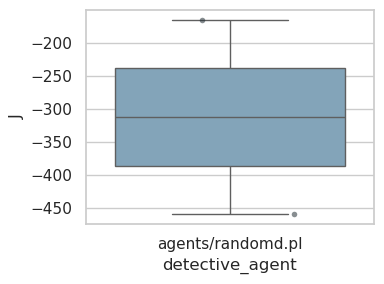

salvo: /home/lucas/dev/web/agents/tools/eval/results/cenario1__randomt__vs__randomd__n2__seed1__9e58596d1cce/figs/score_distribution_by_detective.png


In [25]:
plt.figure(figsize=FIGSIZE)
sns.boxplot(data=matches, x="detective_agent", y="score", color="#7aa6c2")
sns.stripplot(data=matches, x="detective_agent", y="score", color="#263238", alpha=0.55, jitter=0.25, size=4)
plt.ylabel("J")
plt.xticks(rotation=0)
save_fig("score_distribution_by_detective.png")

## Taxa de vitoria por detetive

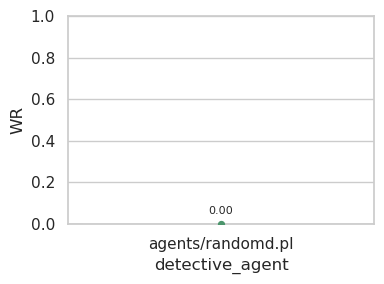

salvo: /home/lucas/dev/web/agents/tools/eval/results/cenario1__randomt__vs__randomd__n2__seed1__9e58596d1cce/figs/win_rate_by_detective.png


In [29]:
data = without_all(summary).copy()

plt.figure(figsize=FIGSIZE)
ax = sns.barplot(data=data, x="detective_agent", y="win_rate", color="#4c956c")
plt.ylabel("WR")
plt.ylim(0, 1)
ax.axhline(0, color="#333333", linewidth=0.8)

for idx, row in data.reset_index(drop=True).iterrows():
    value = float(row["win_rate"])
    label_y = value + 0.03 if value > 0 else 0.04
    ax.text(idx, label_y, f"{value:.2f}", ha="center", va="bottom", fontsize=8)
    if value == 0:
        ax.scatter([idx], [0], color="#4c956c", s=18, zorder=3)

#plt.xticks(rotation=25, ha="right")
save_fig("win_rate_by_detective.png")

## Resultados por detetive

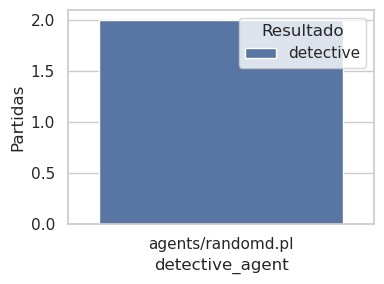

salvo: /home/lucas/dev/web/agents/tools/eval/results/cenario1__randomt__vs__randomd__n2__seed1__9e58596d1cce/figs/outcomes_by_detective.png


In [34]:
data = matches.groupby(["detective_agent", "winner"]).size().reset_index(name="count")

plt.figure(figsize=FIGSIZE)
sns.barplot(data=data, x="detective_agent", y="count", hue="winner")
plt.ylabel("Partidas")
#plt.xticks(rotation=25, ha="right")
plt.legend(title="Resultado")
save_fig("outcomes_by_detective.png")

## Score por rodada

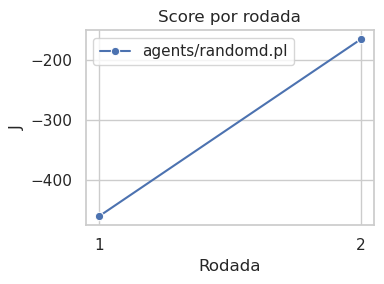

salvo: /home/lucas/dev/web/agents/tools/eval/results/cenario1__randomt__vs__randomd__n2__seed1__9e58596d1cce/figs/score_over_rounds.png


In [36]:
plt.figure(figsize=FIGSIZE)
ax = sns.lineplot(data=matches, x="round", y="score", hue="detective_agent", marker="o", errorbar=None)
plt.title("Score por rodada")
plt.xlabel("Rodada")
plt.ylabel("J")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.legend()
save_fig("score_over_rounds.png")

## Metricas medias por detetive

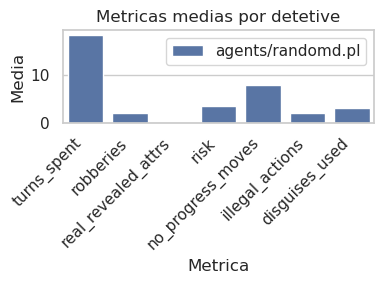

salvo: /home/lucas/dev/web/agents/tools/eval/results/cenario1__randomt__vs__randomd__n2__seed1__9e58596d1cce/figs/mean_metrics_by_detective.png


In [40]:
metrics = [
    "turns_spent",
    "robberies",
    "real_revealed_attrs",
    "risk",
    "no_progress_moves",
    "illegal_actions",
    "disguises_used",
]
available = [col for col in metrics if col in matches.columns]

if available:
    melted = matches.melt(
        id_vars=["detective_agent"],
        value_vars=available,
        var_name="metric",
        value_name="value",
    )

    plt.figure(figsize=FIGSIZE)
    sns.barplot(data=melted, x="metric", y="value", hue="detective_agent", estimator="mean", errorbar=None)
    plt.title("Metricas medias por detetive")
    plt.xlabel("Metrica")
    plt.ylabel("Media")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    save_fig("mean_metrics_by_detective.png")

## Motivos de derrota

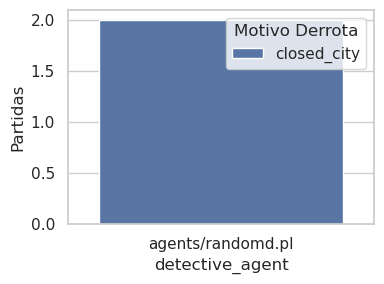

salvo: /home/lucas/dev/web/agents/tools/eval/results/cenario1__randomt__vs__randomd__n2__seed1__9e58596d1cce/figs/loss_reasons.png


In [42]:
data = matches[matches["loss_reason"].fillna("") != ""] if "loss_reason" in matches.columns else pd.DataFrame()

if not data.empty:
    counts = data.groupby(["detective_agent", "loss_reason"]).size().reset_index(name="count")

    plt.figure(figsize=FIGSIZE)
    sns.barplot(data=counts, x="detective_agent", y="count", hue="loss_reason")
    plt.ylabel("Partidas")
    #plt.xticks(rotation=25, ha="right")
    plt.legend(title="Motivo Derrota")
    save_fig("loss_reasons.png")

## Pior, media e melhor score

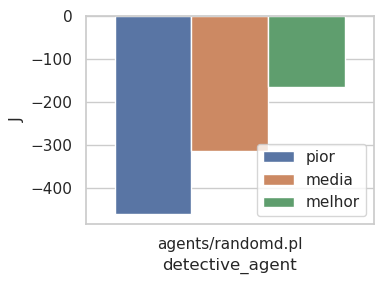

salvo: /home/lucas/dev/web/agents/tools/eval/results/cenario1__randomt__vs__randomd__n2__seed1__9e58596d1cce/figs/best_worst_scores.png


In [45]:
needed = {"detective_agent", "score_best", "score_mean", "score_worst"}

if needed.issubset(summary.columns):
    data = without_all(summary).copy()
    data = data.melt(
        id_vars=["detective_agent"],
        value_vars=["score_best", "score_mean", "score_worst"],
        var_name="kind",
        value_name="score",
    )
    data["kind"] = pd.Categorical(
        data["kind"],
        categories=["score_worst", "score_mean", "score_best"],
        ordered=True,
    )
    labels = {
        "score_worst": "pior",
        "score_mean": "media",
        "score_best": "melhor",
    }
    data["kind"] = data["kind"].map(labels)

    plt.figure(figsize=FIGSIZE)
    sns.barplot(data=data, x="detective_agent", y="score", hue="kind")
    plt.ylabel("J")
    #plt.xticks(rotation=25, ha="right")
    plt.legend(title="")
    save_fig("best_worst_scores.png")

## Score vs exposicao de pistas

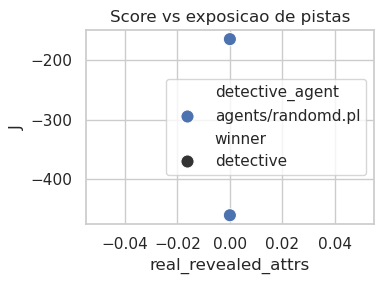

salvo: /home/lucas/dev/web/agents/tools/eval/results/cenario1__randomt__vs__randomd__n2__seed1__9e58596d1cce/figs/score_vs_exposure.png


In [46]:
x_col = "real_revealed_attrs" if "real_revealed_attrs" in matches.columns else "revealed_attrs_total"

if x_col in matches.columns:
    plt.figure(figsize=FIGSIZE)
    sns.scatterplot(data=matches, x=x_col, y="score", hue="detective_agent", style="winner", s=90)
    plt.title("Score vs exposicao de pistas")
    plt.xlabel(x_col)
    plt.ylabel("J")
    plt.legend()
    save_fig("score_vs_exposure.png")